# Stock Data Exploration

This notebook explores the historical price and return behavior of the eight assets used throughout the portfolio analysis.

I examine adjusted prices, normalized performance, daily returns, annualized return and volatility, and correlations between assets.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [4]:
tickers = [
    "AAPL",
    "MSFT",
    "JPM",
    "JNJ",
    "XOM",
    "PG",
    "CAT",
    "NEE"
]

start_date = "2016-01-01"
end_date = "2026-01-01"

In [5]:
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

data.head()

Price           Close                                                         \
Ticker           AAPL        CAT        JNJ        JPM       MSFT        NEE   
Date                                                                           
2016-01-04  23.688673  52.891834  74.967804  48.184067  47.680958  19.617605   
2016-01-05  23.095049  52.339478  75.281143  48.267372  47.898491  19.808903   
2016-01-06  22.643085  51.514877  74.900658  47.570602  47.028397  19.744505   
2016-01-07  21.687454  49.741192  74.027733  45.646877  45.392620  19.831635   
2016-01-08  21.802120  49.235535  73.236870  44.624413  45.531845  19.920656   

Price                                  High             ...       Open  \
Ticker             PG        XOM       AAPL        CAT  ...         PG   
Date                                                    ...              
2016-01-04  58.231094  49.002312  23.693171  52.961852  ...  58.223662   
2016-01-05  58.416855  49.419849  23.801099  53.241885  ...  58.283110   
2016-01-06  57.852139  49.008644  23.018598  52.004974  ...  57.710961   
2016-01-07  57.346909  48.224201  22.514928  50.970328  ...  57.101708   
2016-01-08  56.447826  47.249977  22.285563  50.200173  ...  57.480635   

Price                     Volume                                         \
Ticker            XOM       AAPL      CAT       JNJ       JPM      MSFT   
Date                                                                      
2016-01-04  49.027617  270597600  8586900  12722800  25393200  53778000   
2016-01-05  48.831518  223164000  6139100   6467200  16566700  34079700   
2016-01-06  48.483573  273829600  6639300   7733800  22961500  39518900   
2016-01-07  48.116653  324377600  8601500   9433100  27630900  56564900   
2016-01-08  48.300115  283192000  8278500   9766700  22373300  48754000   

Price                                     
Ticker           NEE        PG       XOM  
Date                                      
2016-01-04   7716400  11529800  20400100  
2016-01-05   8915200   8133700  11993500  
2016-01-06   6983200   9551000  18826900  
2016-01-07  12870800  11973900  21263800  
2016-01-08  14382000   9676400  19033600  

[5 rows x 40 columns]

In [6]:
prices = data["Close"]
prices.head()

Ticker,AAPL,CAT,JNJ,JPM,MSFT,NEE,PG,XOM
Date,,,,,,,,
2016-01-04,23.688673,52.891834,74.967804,48.184067,47.680958,19.617605,58.231094,49.002312
2016-01-05,23.095049,52.339478,75.281143,48.267372,47.898491,19.808903,58.416855,49.419849
2016-01-06,22.643085,51.514877,74.900658,47.570602,47.028397,19.744505,57.852139,49.008644
2016-01-07,21.687454,49.741192,74.027733,45.646877,45.392620,19.831635,57.346909,48.224201
2016-01-08,21.802120,49.235535,73.236870,44.624413,45.531845,19.920656,56.447826,47.249977


In [7]:
prices.shape

(2514, 8)

In [8]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2514 entries, 2016-01-04 to 2025-12-31
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2514 non-null   float64
 1   CAT     2514 non-null   float64
 2   JNJ     2514 non-null   float64
 3   JPM     2514 non-null   float64
 4   MSFT    2514 non-null   float64
 5   NEE     2514 non-null   float64
 6   PG      2514 non-null   float64
 7   XOM     2514 non-null   float64
dtypes: float64(8)
memory usage: 176.8 KB


In [9]:
prices.isna().sum()

Ticker
AAPL    0
CAT     0
JNJ     0
JPM     0
MSFT    0
NEE     0
PG      0
XOM     0
dtype: int64

In [10]:
prices.describe()

Ticker,AAPL,CAT,JNJ,JPM,MSFT,NEE,PG,XOM
count,2514.000000,2514.000000,2514.000000,2514.000000,2514.000000,2514.000000,2514.000000,2514.000000
mean,113.981375,189.506630,127.920343,125.304762,221.390779,52.717305,110.091352,69.090704
std,73.151423,112.681862,26.242348,64.251928,138.970611,18.870275,34.284491,25.504214
min,20.548141,45.614292,71.438782,40.193783,42.737881,19.617605,55.712227,23.670290
25%,41.418405,110.201622,106.151682,83.889347,93.360083,33.914534,71.519289,52.011709
50%,120.052475,161.516655,131.771194,106.877369,211.654953,57.890085,117.407852,56.718586
75%,171.194805,236.725246,147.957672,142.428341,321.842072,68.667515,139.807167,96.204641
max,285.413116,621.810120,210.779739,324.561249,537.646423,84.447388,171.262512,118.610596


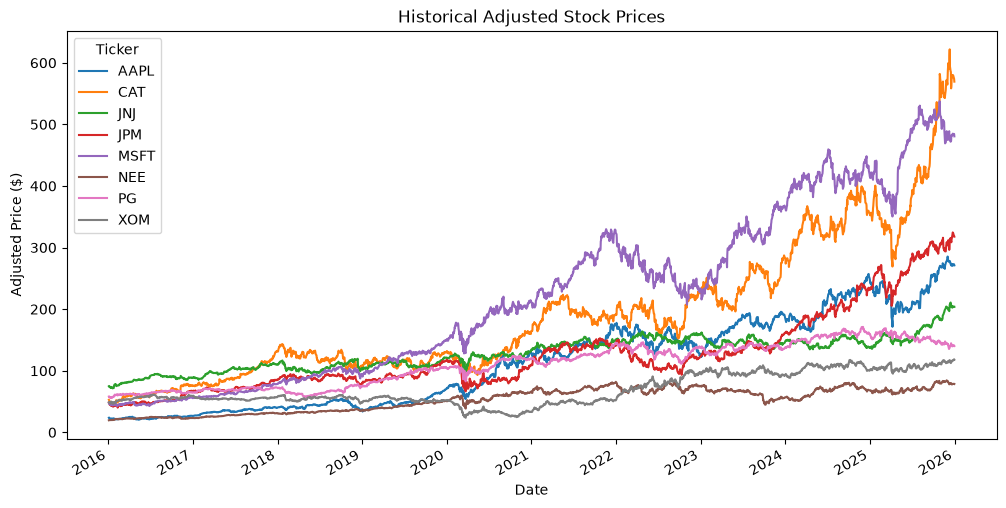

In [11]:
prices.plot(figsize=(12, 6))
plt.title("Historical Adjusted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Price ($)")
plt.legend(title="Ticker")
plt.show()

In [12]:
normalized_prices = prices / prices.iloc[0] * 100

If you invest $100 in each stock at the beginning of the period and hold it, what will be the relative value of each investment over time?

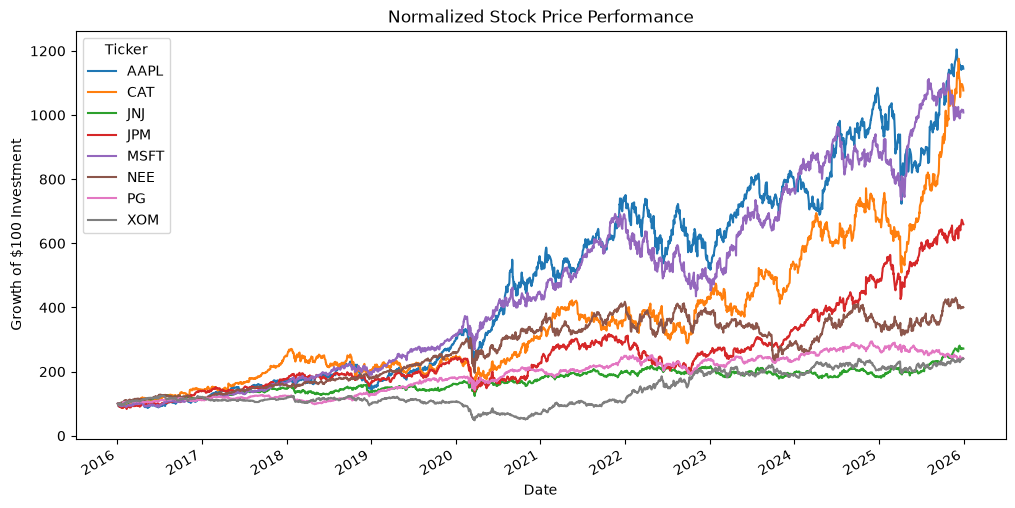

In [13]:
normalized_prices.plot(figsize=(12, 6))
plt.title("Normalized Stock Price Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $100 Investment")
plt.legend(title="Ticker")
plt.show()

In [14]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,AAPL,CAT,JNJ,JPM,MSFT,NEE,PG,XOM
Date,,,,,,,,
2016-01-05,-0.025059,-0.010443,0.004180,0.001729,0.004562,0.009751,0.003190,0.008521
2016-01-06,-0.019570,-0.015755,-0.005054,-0.014436,-0.018165,-0.003251,-0.009667,-0.008321
2016-01-07,-0.042204,-0.034431,-0.011654,-0.040439,-0.034783,0.004413,-0.008733,-0.016006
2016-01-08,0.005287,-0.010166,-0.010683,-0.022399,0.003067,0.004489,-0.015678,-0.020202
2016-01-11,0.016192,-0.028757,-0.006011,-0.001527,-0.000573,0.003899,0.009214,-0.013389


In [15]:
returns.describe()

Ticker,AAPL,CAT,JNJ,JPM,MSFT,NEE,PG,XOM
count,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000
mean,0.001138,0.001129,0.000465,0.000901,0.001062,0.000678,0.000419,0.000504
std,0.018300,0.019135,0.011567,0.017373,0.016854,0.015859,0.011805,0.017551
min,-0.128647,-0.142822,-0.100379,-0.149649,-0.147390,-0.134170,-0.087373,-0.122248
25%,-0.007080,-0.008510,-0.004743,-0.006987,-0.006627,-0.006658,-0.005121,-0.008183
50%,0.001095,0.000842,0.000474,0.000764,0.001049,0.001197,0.000668,0.000459
75%,0.010028,0.011104,0.005939,0.008936,0.009659,0.008305,0.006349,0.009248
max,0.153289,0.116346,0.079977,0.180125,0.142169,0.136904,0.120091,0.126868


In [16]:
annual_returns = returns.mean() * 252
annual_returns.sort_values(ascending=False)

Ticker
AAPL    0.286677
CAT     0.284568
MSFT    0.267554
JPM     0.227134
NEE     0.170965
XOM     0.126946
JNJ     0.117132
PG      0.105659
dtype: float64

In [17]:
annual_volatility = returns.std() * np.sqrt(252)
annual_volatility.sort_values(ascending=False)

Ticker
CAT     0.303762
AAPL    0.290508
XOM     0.278615
JPM     0.275794
MSFT    0.267554
NEE     0.251753
PG      0.187402
JNJ     0.183623
dtype: float64

In [18]:
summary = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_volatility
})
summary

,Annual Return,Annual Volatility
Ticker,,
AAPL,0.286677,0.290508
CAT,0.284568,0.303762
JNJ,0.117132,0.183623
JPM,0.227134,0.275794
MSFT,0.267554,0.267554
NEE,0.170965,0.251753
PG,0.105659,0.187402
XOM,0.126946,0.278615


In [19]:
correlation_matrix = returns.corr()
correlation_matrix

Ticker,AAPL,CAT,JNJ,JPM,MSFT,NEE,PG,XOM
Ticker,,,,,,,,
AAPL,1.000000,0.386918,0.305656,0.416883,0.677422,0.309794,0.345965,0.300180
CAT,0.386918,1.000000,0.286689,0.603608,0.393177,0.202366,0.221264,0.539790
JNJ,0.305656,0.286689,1.000000,0.350531,0.317446,0.381295,0.519314,0.294160
JPM,0.416883,0.603608,0.350531,1.000000,0.435311,0.251149,0.302475,0.534880
MSFT,0.677422,0.393177,0.317446,0.435311,1.000000,0.328001,0.361216,0.262350
NEE,0.309794,0.202366,0.381295,0.251149,0.328001,1.000000,0.477411,0.241722
PG,0.345965,0.221264,0.519314,0.302475,0.361216,0.477411,1.000000,0.229569
XOM,0.300180,0.539790,0.294160,0.534880,0.262350,0.241722,0.229569,1.000000


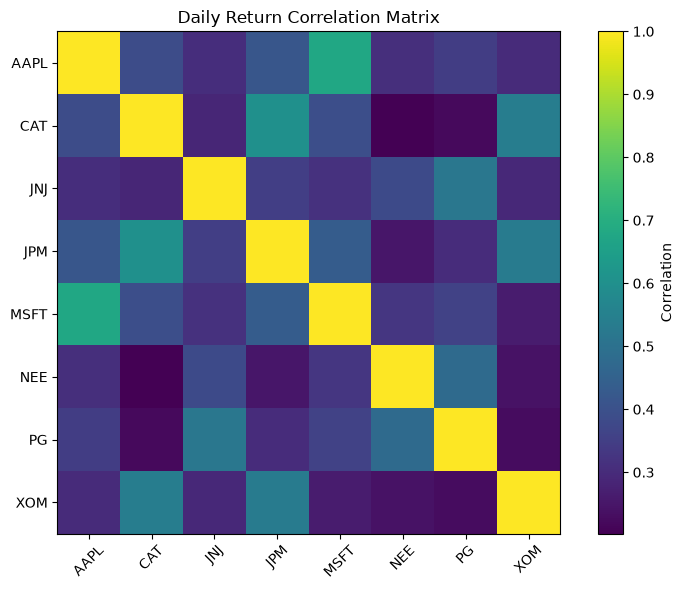

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation_matrix)
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45)
ax.set_yticklabels(correlation_matrix.index)
plt.colorbar(image, ax=ax, label="Correlation")
plt.title("Daily Return Correlation Matrix")
plt.tight_layout()
plt.show()

## Conclusion

The eight stocks show substantial differences in both historical return and risk. AAPL and CAT had the highest annualized returns over the sample period, but they were also among the most volatile assets. In contrast, JNJ and PG had lower historical returns and substantially lower volatility.

The correlation matrix also shows that the assets are not perfectly correlated. Some pairs, such as AAPL and MSFT, have relatively high correlations, while others have much weaker relationships. This suggests that combining assets from different sectors may provide diversification benefits.

Overall, the exploratory analysis shows that portfolio construction involves a trade-off between return and risk, while correlations between assets also matter for total portfolio risk. These relationships provide the motivation for the portfolio mathematics and optimization developed in the following notebooks.